In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [3]:
cols_to_use = ['CrashSeverity', 'CrashDateTime', 'NumberOfUnits', 'LightCondition', 'Weather', 'MannerOfCollision', 'RoadwayDivided', 'IntersectionOrApproachRelated', 'NumberOfApproaches', 'WithinInterchangeArea', 'Latitude', 'Longitude','RoadContour','RoadCondition','RoadSurface', 'AnimalRelated','AnimalDeerRelated','AlcoholRelated','DrugRelated','BicycleRelated','MotorCycleRelated','SpeedRelated','PedestrianRelated',	'SemiTruckRelated','SmallTruckRelated','YouthRelated','TeenRelated','DUI21Related','SeniorRelated',	'CommercialRelated','CommercialAtFault']

df = pd.read_csv("C:/Users/alyss/Downloads/OH260225190059543S845PK/CrashStatistics.csv", usecols=cols_to_use, low_memory=False)

#print(df)


In [4]:
#arcgis_db = df[['CrashSeverity', 'Latitude', 'Longitude']]
#print(arcgis_db)

#arcgis_db.to_csv('raw_crash_data.csv', index=False)

In [5]:
#df = pd.read_csv("C:/Users/alyss/Downloads/OH260225190059543S845PK/CrashStatistics.csv")
#df.drop(columns=['LocalReportNumber','DocumentNumber','HitSkip', 'SecondaryCrash','UnitInError','County','FIPSPlaceCode', 'PhotosTaken', 'OH2', 'OH3','OH1P','OHOther','PrivateProperty','ReportingAgencyNCIC','Narrative','ReportTakenBy','Supplement','CrashReportedDateTime','DispatchedDateTime','ArrivedDateTime','SceneClearedDateTime','OtherInvestigationTime','OfficerName','OfficerBadgeNumber','CheckedByOfficerName','CheckedByBadgeNumber'], inplace=True)

In [6]:
df["CrashDateTime"] = pd.to_datetime(df["CrashDateTime"])
df["Year"] = df["CrashDateTime"].dt.year
df["Month"] = df["CrashDateTime"].dt.month
df["Day"] = df["CrashDateTime"].dt.day
df["Hour"] = df["CrashDateTime"].dt.hour
df["Minute"] = df["CrashDateTime"].dt.minute
df = df.drop(columns=["CrashDateTime"])

In [7]:
le = LabelEncoder()

SeverityOrder = {'Property Damage Only': 0, 'Injury Possible': 1, 'Minor Injury Suspected': 2, 'Serious Injury Suspected': 3, 'Fatal': 4}
df['EncodedCrashSeverity'] = df['CrashSeverity'].map(SeverityOrder)

label_map = dict(zip(df['CrashSeverity'], df['EncodedCrashSeverity']))

#mapping = {label: index for index, label in enumerate(le.classes_)}

In [8]:
# List of feature and target columns
x = df.drop(columns=['CrashSeverity', 'EncodedCrashSeverity'])
y = df['EncodedCrashSeverity']

In [9]:
#Split testing and training data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
#Separate numeric and categorical features
numeric_features = x.select_dtypes(include="number").columns
categorical_features = x.select_dtypes(exclude="number").columns
print(numeric_features)
print(categorical_features)

Index(['NumberOfUnits', 'Latitude', 'Longitude', 'NumberOfApproaches', 'Year',
       'Month', 'Day', 'Hour', 'Minute'],
      dtype='str')
Index(['IntersectionOrApproachRelated', 'WithinInterchangeArea',
       'MannerOfCollision', 'Weather', 'LightCondition', 'RoadwayDivided',
       'RoadContour', 'RoadCondition', 'RoadSurface', 'AnimalRelated',
       'AnimalDeerRelated', 'AlcoholRelated', 'DrugRelated', 'BicycleRelated',
       'MotorCycleRelated', 'SpeedRelated', 'PedestrianRelated',
       'SemiTruckRelated', 'SmallTruckRelated', 'YouthRelated', 'TeenRelated',
       'DUI21Related', 'SeniorRelated', 'CommercialRelated',
       'CommercialAtFault'],
      dtype='str')


Core code

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='most_frequent')), # error in manner_of_collision for angle
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [12]:
from sklearn.compose import ColumnTransformer

data_transformer = ColumnTransformer(
  transformers = [
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, 
      categorical_features)
    ])

transformed_data = data_transformer.fit_transform(X_train)

#column_names = data_transformer.get_feature_names_out()

In [13]:
#Feature selection
from sklearn.feature_selection import SelectFromModel
feature_selector = SelectFromModel(
    estimator=XGBClassifier(
        n_estimators=200,
        eval_metric="logloss", #can remove eval_metric?
        random_state=42
    ),
    threshold="1.25*mean"
)

In [14]:
model_1 = XGBClassifier(
    n_estimators=75,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
#parameters determined by bayesian optimization

In [15]:
xgb_pipeline =  Pipeline(steps = [
    ('preprocessing', data_transformer),
    ("feature_selection", feature_selector),
    ('XGB', model_1)
    ])

#xgb_pipeline = xgb_pipeline.fit(X_train, y_train)
#prediction = xgb_pipeline.predict(X_test)

In [16]:
#Make weights count to account for uneven split of data

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

#sklearn.set_config(enable_metadata_routing=True)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(zip(np.unique(y_train), weights))
sample_weights = np.array([class_weights_dict[cls] for cls in y_train])

xgb_pipeline = xgb_pipeline.fit(X_train, y_train, XGB__sample_weight=sample_weights)
y_pred = xgb_pipeline.predict(X_test)

Model Analysis and Comparison

In [17]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro-Averaged F1 Score: {macro_f1:.4f}")

#Precision: False positives (higher is better)
#Recall (Sensitivity): How many actual positives were detected (higher is better)
#F1: harmonic mean of Precision and Recall

              precision    recall  f1-score   support

           0       0.88      0.31      0.46      1372
           1       0.10      0.31      0.15       143
           2       0.20      0.52      0.29       330
           3       0.19      0.28      0.23        53
           4       0.13      0.50      0.21        14

    accuracy                           0.35      1912
   macro avg       0.30      0.39      0.27      1912
weighted avg       0.68      0.35      0.40      1912

Macro-Averaged F1 Score: 0.2671


In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# Strategy "most_frequent" always predicts the majority class
dummy_majority = DummyClassifier(strategy="most_frequent")
dummy_majority.fit(X_train, y_train)

dummy_preds = dummy_majority.predict(X_test)

print("--- Baseline: Majority Class Strategy ---")
print(classification_report(y_test, dummy_preds))

--- Baseline: Majority Class Strategy ---
              precision    recall  f1-score   support

           0       0.72      1.00      0.84      1372
           1       0.00      0.00      0.00       143
           2       0.00      0.00      0.00       330
           3       0.00      0.00      0.00        53
           4       0.00      0.00      0.00        14

    accuracy                           0.72      1912
   macro avg       0.14      0.20      0.17      1912
weighted avg       0.51      0.72      0.60      1912



c:\Users\alyss\Downloads\csci 2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyss\Downloads\csci 2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyss\Downloads\csci 2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [19]:
from sklearn.linear_model import LogisticRegression

# Simple linear baseline
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

lr_preds = log_reg.predict(X_test)

print("--- Baseline: Logistic Regression ---")
print(classification_report(y_test, lr_preds))

ValueError: could not convert string to float: 'Angle'

In [17]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

print("Test accuracy:", xgb_pipeline.score(X_test, y_test))

y_probas = xgb_pipeline.predict_proba(X_test)[:, 1]

PrecisionRecallDisplay.from_predictions(y_test, y_probas, name="XGBoost")
plt.show()

Test accuracy: 0.7201882845188284


ValueError: The target y is not binary. Got multiclass type of target.

Hyperparameter optimization

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'XGB__n_estimators': [25, 50, 75],
    'XGB__learning_rate': [0.01, 0.05, 0.1],
    'XGB__max_depth': [3, 5, 7, 8],
    'XGB__subsample': [0.8, 1.0],
    'XGB__colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline, 
    param_grid=param_grid, 
    cv=3, #cross validation folds
    scoring='accuracy', 
    n_jobs=-1, #uses all cpu cores
    verbose=1 #print what it's doing
)

grid_search.fit(X_train, y_train)

print("\nSearch Results")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"Final Test Accuracy with Best Model: {test_accuracy:.4f}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits

Search Results
Best Parameters: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.1, 'XGB__max_depth': 5, 'XGB__n_estimators': 75, 'XGB__subsample': 0.8}
Best Cross-Validation Score: 0.7289
Final Test Accuracy with Best Model: 0.7202


Attempting to print feature importance

In [70]:
import numpy as np
def get_pipeline_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocessing']
    ohe_categories = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    all_names = np.concatenate([numeric_features, ohe_categories])
    
    #filter by feature_selection
    selector_mask = pipeline.named_steps['feature_selection'].get_support()
    return all_names[selector_mask]

feature_names = get_pipeline_feature_names(xgb_pipeline)
importances = xgb_pipeline.named_steps['XGB'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
print(importance_df.sort_values(by='importance', ascending=False).head(10))

print(f"Model Score: {xgb_pipeline.score(X_test, y_test):.4f}")

                                              feature  importance
13        MannerOfCollision_Sideswipe; same direction    0.096160
7                             MannerOfCollision_Angle    0.085190
8                           MannerOfCollision_Backing    0.081551
9                           MannerOfCollision_Head-on    0.078931
0                                       NumberOfUnits    0.070835
10  MannerOfCollision_Not Collision Between Two Ve...    0.054777
19                               RoadwayDivided_False    0.052445
12    MannerOfCollision_Sideswipe; opposite direction    0.050792
18                            LightCondition_Daylight    0.047439
6                 IntersectionOrApproachRelated_False    0.044052
Model Score: 0.7171


In [26]:
print(f"Feature importances: {model_1.feature_importances_}")
print("Feature importance length: "+str(len(model_1.feature_importances_)))
print("Features length: "+str(len(x.columns)))

#Notes: it stores the result from the pipeline and calls model_1 that has already been fitted with the previous kernel

feature_list = model_1.get_booster().feature_names
print(feature_list)

original_feature_names = X_train.columns.tolist()
print(original_feature_names)

importances = model_1.feature_importances_
feature_importance_df = pd.DataFrame(zip(column_names, importances), columns=['feature', 'importance']).set_index('feature')
print(feature_importance_df)

Feature importances: [0.02088491 0.01486874 0.01465714 0.01340142 0.01216848 0.01095937
 0.01167318 0.01141563 0.01583874 0.02672494 0.04046358 0.02364161
 0.01490354 0.01684661 0.01742198 0.02154216 0.05577403 0.01264492
 0.01068981 0.00931806 0.01109964 0.01468269 0.01428017 0.0207033
 0.0100478  0.0101286  0.01025045 0.01519263 0.02318317 0.01410666
 0.02111433 0.07086496 0.07122252 0.02561445 0.06025021 0.03512229
 0.05913735 0.02118087 0.03906274 0.01050429 0.0113263  0.01162487
 0.01298625 0.02079702 0.0096776 ]
Feature importance length: 45
Features length: 34
None
['NumberOfUnits', 'Latitude', 'Longitude', 'IntersectionOrApproachRelated', 'NumberOfApproaches', 'WithinInterchangeArea', 'MannerOfCollision', 'Weather', 'LightCondition', 'RoadwayDivided', 'RoadContour', 'RoadCondition', 'RoadSurface', 'AnimalRelated', 'AnimalDeerRelated', 'AlcoholRelated', 'DrugRelated', 'BicycleRelated', 'MotorCycleRelated', 'SpeedRelated', 'PedestrianRelated', 'SemiTruckRelated', 'SmallTruckRelat

In [27]:
clf = XGBClassifier(n_estimators=5, random_state=42)
clf = clf.fit(transformed_data, y_train)

#feature_list = clf.get_booster().feature_names

#print(feature_list)

importances = clf.feature_importances_
column_names = data_transformer.get_feature_names_out()

#print(f"Feature importances: {clf.feature_importances_}")
#print("Feature importance length: "+str(len(clf.feature_importances_)))
#print("Features length: "+str(len(x.columns)))

feature_importance_df = pd.DataFrame(zip(column_names, importances), columns=['feature', 'importance']).set_index('feature')
df_sorted = feature_importance_df.sort_values(by='importance', ascending=False)
print(df_sorted)



                                                  importance
feature                                                     
cat__DrugRelated_False                              0.114097
cat__AnimalRelated_False                            0.112086
cat__MannerOfCollision_Sideswipe; same direction    0.076164
cat__MotorCycleRelated_False                        0.056824
cat__MannerOfCollision_Backing                      0.048096
...                                                      ...
cat__DUI21Related_False                             0.000000
cat__SeniorRelated_True                             0.000000
cat__CommercialRelated_True                         0.000000
cat__CommercialAtFault_False                        0.000000
cat__CommercialAtFault_True                         0.000000

[90 rows x 1 columns]


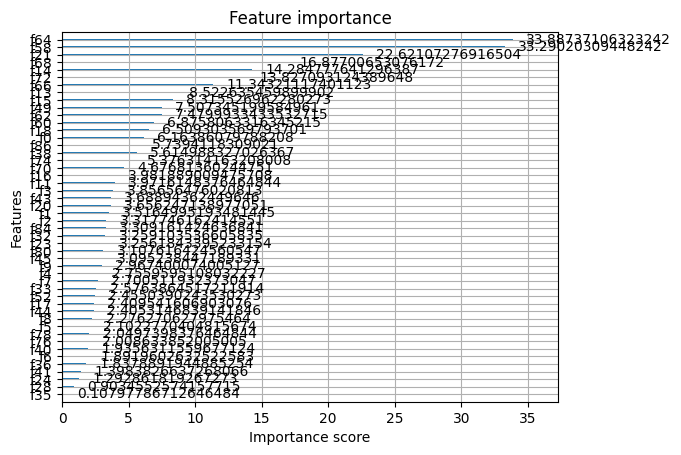

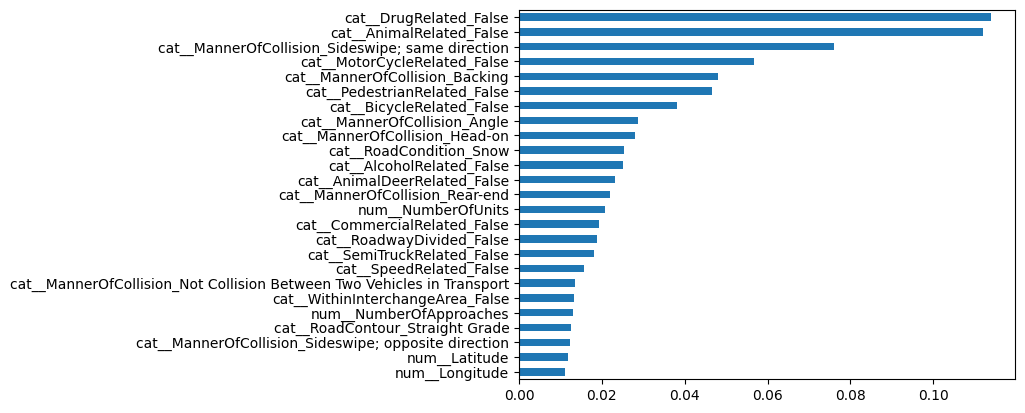

In [28]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(clf.get_booster(), importance_type='gain')
plt.show()

pd.Series(clf.feature_importances_, index=column_names).nlargest(25).plot(kind='barh').invert_yaxis()

In [29]:
# Get feature importances
importances = model_1.feature_importances_

# Map to names and sort
feature_imp_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances})
new_feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)
print(new_feature_imp_df)

ValueError: All arrays must be of the same length

In [ ]:

# 3. Use SelectFromModel to select features based on the trained estimator
# By default, the threshold is the mean of the feature importances
model_selection = SelectFromModel(clf, prefit=True) 

X_train_selected = model_selection.transform(transformed_data)
print(X_train_selected)

selected_feature_indices = model_selection.get_support(indices=True)
selected_feature_names = [X_train_selected[i] for i in selected_feature_indices]
#print("Selected feature names:", selected_feature_names)


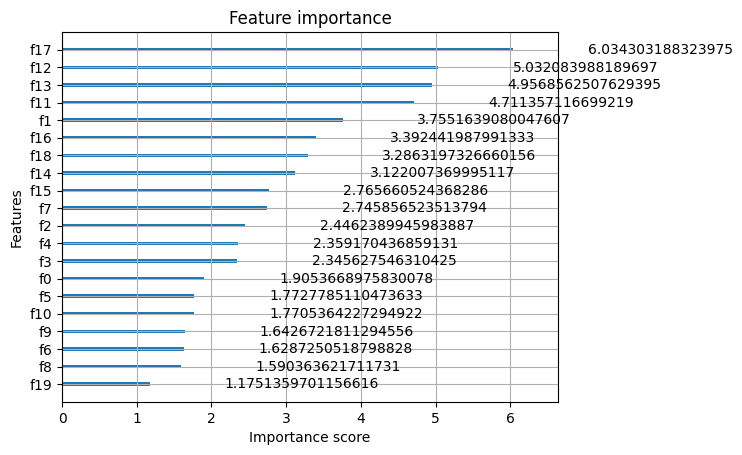

In [25]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#print(model_1.feature_names_in_)
#feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
plot_importance(model_1.get_booster(), importance_type='gain')
plt.show()

To do in the future: Cross validation fold score


To do: 

In [ ]:
#Cross correlation matrix?


Exporting xgboost predictions

In [ ]:
import geopandas as gpd
df['prediction'] = xgb_pipeline.predict(x)

gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

gdf.to_file('ordered_predictions.geojson', driver='GeoJSON')


import os
print(os.getcwd())

c:\Users\alyss\Downloads\csci 2026\jr_is\jris\rf_code
